# LeetCode #240: Search a 2D Matrix II

https://leetcode.com/problems/search-a-2d-matrix-ii/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (nested loops)** | $O(m \times n)$ | $O(1)$ |
| **Binary Search per row** | $O(m \log n)$ | $O(1)$ |
| **Optimal: Staircase Search ★** | $O(m + n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (nested loops)
Check every cell. $O(m \times n)$ — completely ignores the column-sorted property.

### Binary Search per row
Binary-search each row for the target. $O(m \log n)$ — uses row sorting but ignores column sorting.

### Optimal: Staircase Search ★
Start at the top-right corner. The value there is the largest in its row and smallest in its column. If `val > target` move left (eliminate this column); if `val < target` move down (eliminate this row). Each step eliminates a row or column in $O(1)$, giving $O(m + n)$ total.

**Why this is better than Binary Search per row:** $O(m + n)$ beats $O(m \log n)$ for wide matrices, and it exploits the column-sorted property that per-row binary search ignores.

**Constraints:**
* m == matrix.length, n == matrix[i].length
* 1 <= n, m <= 300
* -10^9 <= matrix[i][j] <= 10^9
* All integers in each row are sorted in non-decreasing order
* All integers in each column are sorted in non-decreasing order


## Solutions

### C#

In [ ]:
public bool SearchMatrix(int[][] matrix, int target) {
    int row = 0, col = matrix[0].Length - 1;  // Start at top-right corner
    while (row < matrix.Length && col >= 0) {
        if (matrix[row][col] == target) return true;
        // Too large: eliminate this column (move left)
        if (matrix[row][col] > target) col--;
        // Too small: eliminate this row (move down)
        else row++;
    }
    return false;
}


### Python

In [ ]:
def searchMatrix(self, matrix: list[list[int]], target: int) -> bool:
    row, col = 0, len(matrix[0]) - 1  # Start at top-right corner
    while row < len(matrix) and col >= 0:
        if matrix[row][col] == target:
            return True
        # Too large: eliminate this column (move left)
        if matrix[row][col] > target:
            col -= 1
        # Too small: eliminate this row (move down)
        else:
            row += 1
    return False


### Go

In [ ]:
func searchMatrix(matrix [][]int, target int) bool {
    row, col := 0, len(matrix[0])-1  // Start at top-right corner
    for row < len(matrix) && col >= 0 {
        if matrix[row][col] == target {
            return true
        }
        // Too large: eliminate this column (move left)
        if matrix[row][col] > target {
            col--
        } else {
            // Too small: eliminate this row (move down)
            row++
        }
    }
    return false
}


### Rust

In [ ]:
pub fn search_matrix(matrix: Vec<Vec<i32>>, target: i32) -> bool {
    let (mut row, mut col) = (0usize, matrix[0].len() - 1);
    while row < matrix.len() {
        if matrix[row][col] == target { return true; }
        // Too large: eliminate this column (move left)
        if matrix[row][col] > target {
            if col == 0 { break; }
            col -= 1;
        } else {
            // Too small: eliminate this row (move down)
            row += 1;
        }
    }
    false
}


## Example Scenarios

**1. Common Case**
**Input:** matrix = [[1,4,7,11],[2,5,8,12],[3,6,9,16],[10,13,14,17]], target = 5
Start (0,3)=11>5→col=2. (0,2)=7>5→col=1. (0,1)=4<5→row=1. (1,1)=5=target→true. Four steps to eliminate columns and rows.

**2. Slightly Complex**
**Input:** Same matrix, target = 20
Every value is ≤ 17 < 20. Starting top-right, each cell is smaller → row++ repeatedly until row=4 (out of bounds) → false. Traverses the entire rightmost column in $O(m)$ steps.

**3. Edge Case: Time Factor**
**Input:** 300×300 matrix, target not present, search reaches bottom-left corner
Worst case: every step eliminates exactly one row or column. Maximum steps = $m + n - 1 = 599$. Compares favorably to brute-force $300 \times 300 = 90000$ cell checks.

**4. Edge Case: Space Factor**
**Input:** matrix = [[1]], target = 2
Start (0,0)=1<2→row=1; row≥1=matrix.length → false. Single comparison, $O(1)$ space: only row, col, and the matrix reference.

**5. Almost-Impossible but Plausible**
**Input:** matrix = [[-10^9]], target = -10^9
Start (0,0)=target → return true immediately. Extreme negative values handled correctly: comparison operators work on signed integers, no overflow in staircase arithmetic.


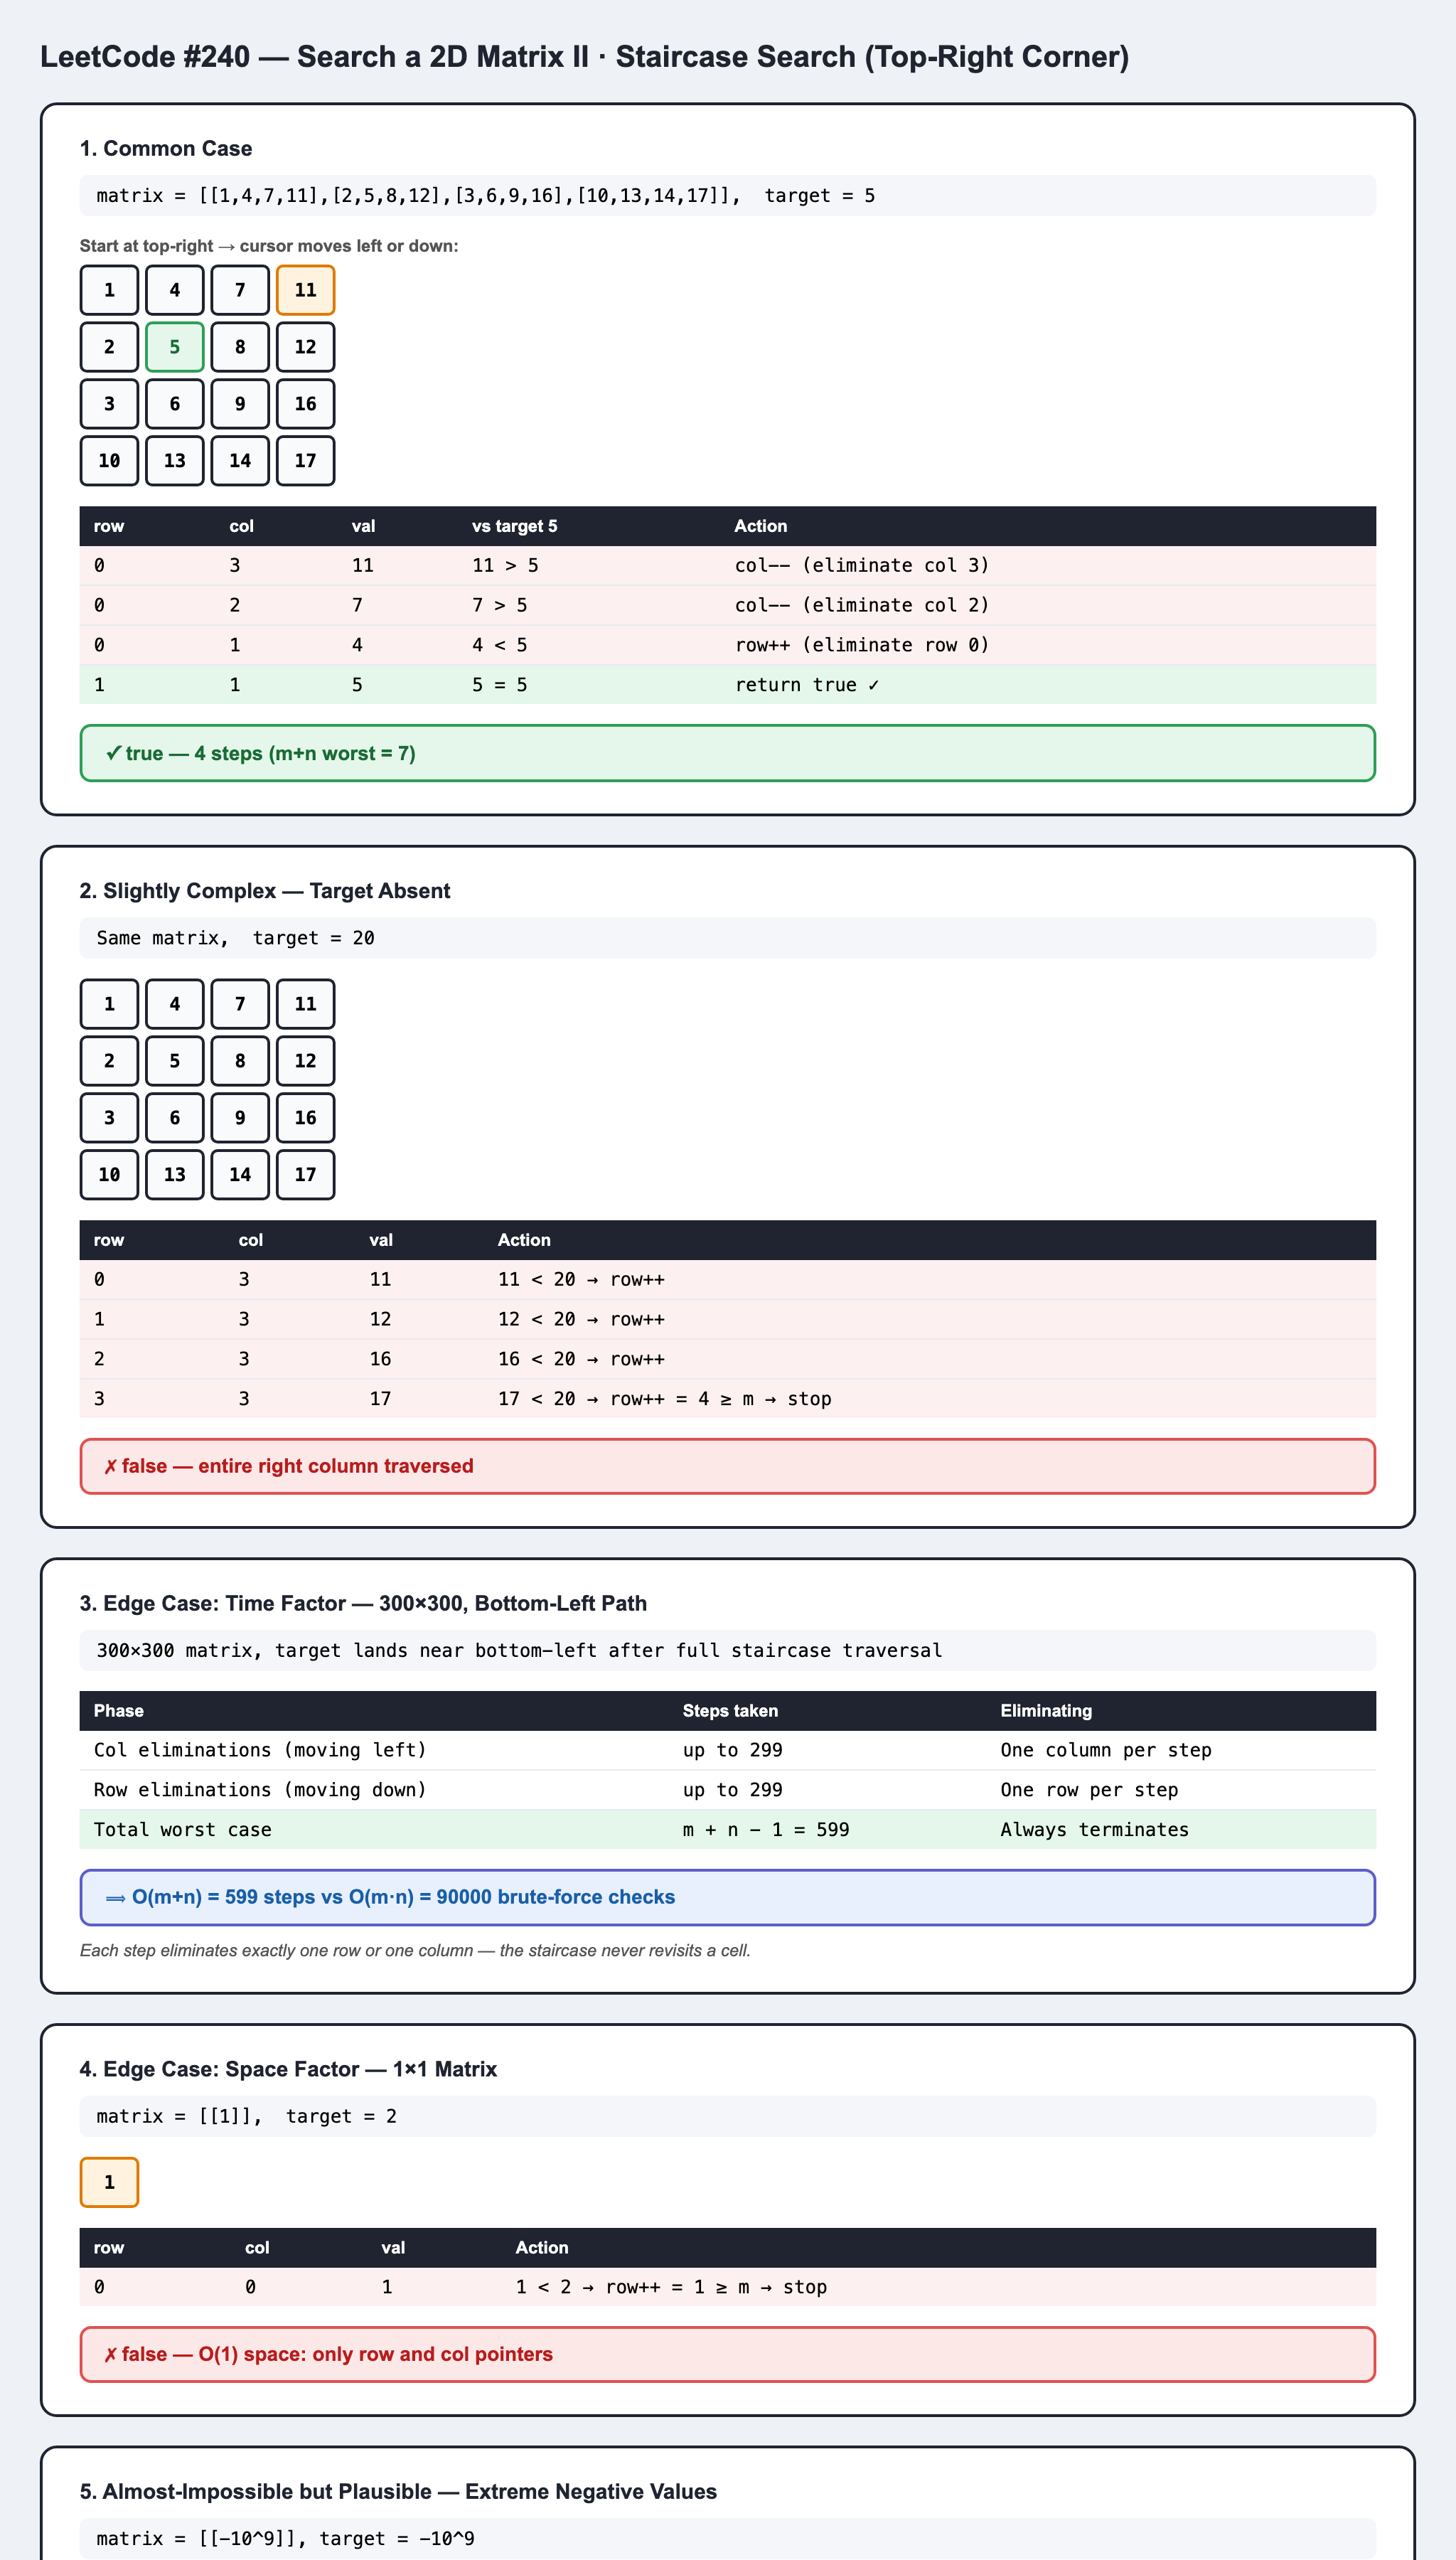